Clustering with K-means requires specifying a presumed number of clusters, which is often problematic. Typically, the proposed solution is the elbow method, but this approach can be, well, not particularly convincing. Therefore, we aim to explore an alternative solution using self-organizing Kohonen maps (SOMs). This technique projects our multidimensional data space into a 2D map while preserving the topology. In simple terms, data points that are close in the n-dimensional space will remain close on the 2D map. This visualization will help us to determine the number of clusters. Once we've established the appropriate k, we perform K-means clustering and label our data accordingly.

# 1) Overview

In [2]:
import numpy as np
import pandas as pd
df = pd.read_csv('Country-data.csv')
df.set_index('country', inplace=True)
df.shape, df.isnull().values.any()

((167, 9), False)

In [3]:
df.head(3)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460


In [4]:
data_dict = pd.read_csv('data-dictionary.csv')
for index in data_dict.index:
    print('{}\n info: {}\n'.format(data_dict.loc[index, 'Column Name'], data_dict.loc[index, 'Description']))

country
 info: Name of the country

child_mort
 info: Death of children under 5 years of age per 1000 live births

exports
 info: Exports of goods and services. Given as %age of the Total GDP

health
 info: Total health spending as %age of Total GDP

imports
 info: Imports of goods and services. Given as %age of the Total GDP

Income
 info: Net income per person

Inflation
 info: The measurement of the annual growth rate of the Total GDP

life_expec
 info: The average number of years a new born child would live if the current mortality patterns are to remain the same

total_fer
 info: The number of children that would be born to each woman if the current age-fertility rates remain the same.

gdpp
 info: The GDP per capita. Calculated as the Total GDP divided by the total population.



In [5]:
def features_info(df):
    feature_info = {
        'feature': df.columns,
        'dtype': [df[col].dtype for col in df.columns],
        'unique_vals': [df[col].nunique() for col in df.columns]}
    features_df = pd.DataFrame(feature_info)
    features_df.set_index('feature', inplace=True)
    features_df.sort_values(by='unique_vals', ascending=False, inplace=True)
    return features_df
# all variables are continous, which is fine
features_info(df)

,dtype,unique_vals
feature,,
gdpp,int64,157
income,int64,156
inflation,float64,156
imports,float64,151
exports,float64,147
health,float64,147
child_mort,float64,139
total_fer,float64,138
life_expec,float64,127


In [6]:
df.describe().applymap(lambda x: round(x, 2))

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.79,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


# 2) Preprocessing

In [7]:
# this is what somoclu likes
for col in df.columns:
    df[col] = df[col].astype('float32')

In [8]:
# these units are arbitrary and we will be calculating Euclidean distance
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data = scaler.fit_transform(df)

In [9]:
# Our data might be colinear and it is benefical to apply PCA for numerous reasons
from sklearn.decomposition import PCA
pca = PCA(n_components=9, svd_solver='full')
pca.fit(data)

explained_variance_ratio=0
components = 0
while explained_variance_ratio < 0.95:
    explained_variance_ratio += pca.explained_variance_ratio_[components]
    components += 1
print('no. of principal components: {}'.format(components))
print('explained_variance_ratio: {}'.format(explained_variance_ratio))

no. of principal components: 6
explained_variance_ratio: 0.970152398571372


In [10]:
pca = PCA(n_components=6, svd_solver='full')
data = pca.fit_transform(data)

# 3) Emergent SOM

In [11]:
import somoclu
som = somoclu.Somoclu(32, 32, maptype="toroid", compactsupport=False)
som.train(data)

It is suspected that using a borderless U-matrix (map) is advantageous because a bordered map might introduce distortions that are best avoided. Therefore, a toroidal map was chosen, which means in practical terms that the upper edge of the map is effectively adjacent to the lower edge, and the left edge is adjacent to the right edge. Note how the edges of the map seamlessly connect to the opposite side.

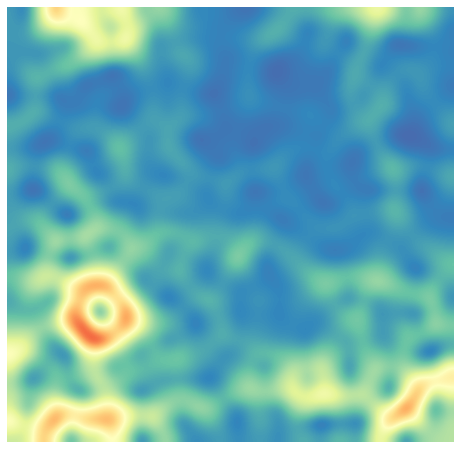

In [14]:
import matplotlib.pyplot as plt
num_bmus = len(som.bmus)
colors = plt.cm.rainbow(np.linspace(0, 1, num_bmus))
som.view_umatrix(bestmatchcolors=colors)
plt.show()

How to read a U-matrix? <br><br>Most of the data are located in the blue regions of the map, while cluster boundaries are indicated by reddish and yellowish lines. This suggests the presence of three clusters. The first cluster is situated to the right of the large red 'o' and extends between two yellow lines on the right. Both these yellow lines actually represent the boundary with the second cluster only (note that the region near the lower edge of the plot is effectively close to the upper edge due to the toroidal nature of the map). The third cluster is partially depicted on both the right and left sides of the plot, with distinguishable yellow lines separating it from the second cluster. <br><br>Well, at least this is how I see it. Clearly we can see that there is much more microstructure there in our data, according to the map, but still - it is probably more intuitive than the elbow method.

# 4) K-means labeling

In [48]:
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans

pipe = make_pipeline(StandardScaler(), 
                     PCA(n_components=6, svd_solver='full'), 
                     KMeans(n_clusters=3, n_init=25))
pipe.fit(df)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=6, svd_solver='full')),
                ('kmeans', KMeans(n_clusters=3, n_init=25))])

In [49]:
clusters = pipe.predict(df)
df['cluster'] = clusters.tolist()
cluster_means = df.groupby('cluster').mean()
cluster_means = cluster_means[['gdpp'] + [col for col in df.columns if col != 'cluster' and col != 'gdpp']]
cluster_means

,gdpp,child_mort,exports,health,imports,income,inflation,life_expec,total_fer
cluster,,,,,,,,,
0,6484.847059,22.287059,40.283400,6.225647,47.518422,12317.294118,7.616424,72.629412,2.314235
1,1826.130435,93.841304,28.837174,6.346957,42.128261,3738.978261,12.087065,59.232609,5.054348
2,42494.444444,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778


In [50]:
df['cluster'] = df['cluster'].apply(lambda x: 'developing' if x==0 else ('undeveloped' if x==1 else 'developed'))
df.sample(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
country,,,,,,,,,,
Jamaica,18.1,31.3,4.81,49.6,8000,9.810,74.7,2.17,4680,developing
Timor-Leste,62.6,2.2,9.12,27.8,1850,26.500,71.1,6.23,3600,undeveloped
South Korea,4.1,49.4,6.93,46.2,30400,3.160,80.1,1.23,22100,developed
Lithuania,6.1,65.3,7.04,67.2,21100,2.380,73.2,1.50,12000,developing
Spain,3.8,25.5,9.54,26.8,32500,0.160,81.9,1.37,30700,developed
Barbados,14.2,39.5,7.97,48.7,15300,0.321,76.7,1.78,16000,developing
Chile,8.7,37.7,7.96,31.3,19400,8.960,79.1,1.88,12900,developing
Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,developed
Kyrgyz Republic,29.6,51.6,6.18,81.7,2790,10.000,68.5,3.10,880,developing


In [51]:
df['cluster'].value_counts()

developing     85
undeveloped    46
developed      36
Name: cluster, dtype: int64